In [3]:
from functools import partial

import jax.numpy as jnp
import typer
from jax import Array, jit, random, vmap
from jax._src.prng import PRNGKeyArray

from bpd import DATA_DIR
from bpd.draw import draw_exponential
from bpd.io import save_dataset
from bpd.likelihood import gaussian_image_loglikelihood
from bpd.pipelines import pipeline_interim_samples_one_galaxy
from bpd.prior import interim_gprops_logprior
from bpd.sample import (
    get_target_images,
    get_true_params_from_galaxy_params,
    sample_galaxy_params_skew,
)
from bpd.utils import DEFAULT_HYPERPARAMS
import matplotlib.pyplot as plt 

from bpd.chains import run_inference_nuts


In [28]:
import numpy as np 
from tqdm import tqdm
from blackjax.diagnostics import potential_scale_reduction

def get_rhat_all(samples: dict[str, np.ndarray]) -> dict[str, np.ndarray]:
    """Obtain r-hats for all chains and parameters."""
    print("INFO: Computing R-hats...")
    n_gals, n_chains_per_gal, n_samples = samples["lf"].shape

    rhat_dict = {}
    for p in samples:
        rhat = []
        for ii in tqdm(range(n_gals)):
            chains = samples[p][ii]
            assert chains.shape == (n_chains_per_gal, n_samples)
            rhat.append(potential_scale_reduction(chains))
        rhat_dict[p] = np.array(rhat)

    return rhat_dict

def _init_fnc(key: PRNGKeyArray, data: Array, true_params: dict):
    image = data
    assert image.ndim == 2
    assert image.shape[0] == image.shape[1]
    flux = image.sum()

    k1, k2, k3 = random.split(key, 3)

    tlhlr = true_params["lhlr"]
    lhlr = random.uniform(k1, shape=(), minval=tlhlr - 0.015, maxval=tlhlr + 0.015)

    te1 = true_params["e1"]
    e1 = random.uniform(k2, shape=(), minval=te1 - 0.1, maxval=te1 + 0.1)

    te2 = true_params["e2"]
    e2 = random.uniform(k3, shape=(), minval=te2 - 0.1, maxval=te2 + 0.1)
    return {
        "lf": jnp.log10(flux),
        "lhlr": lhlr,
        "e1": e1,
        "e2": e2,
        "dx": 0.0,
        "dy": 0.0,
    }

In [5]:
seed = 42 

n_samples: int = 500
n_gals: int = 500
sigma_e_int: float = 0.3
slen: int = 63
fft_size: int = 256
background: float = 1.0
initial_step_size: float = 0.1

In [6]:
rng_key = random.key(seed)
pkey, nkey, gkey = random.split(rng_key, 3)

In [7]:
# galaxy parameters from prior
k1, k2 = random.split(pkey)
galaxy_params = sample_galaxy_params_skew(k1, n=n_gals, **DEFAULT_HYPERPARAMS)
assert galaxy_params["x"].shape == (n_gals,)
assert galaxy_params["e1"].shape == (n_gals,)

# replace fluxes with only low SNR ones
galaxy_params['lf'] = random.uniform(k2, minval=2.0, maxval=2.2, shape=(n_gals,))

(array([32., 25., 27., 26., 23., 24., 22., 27., 15., 24., 27., 19., 24.,
        22., 24., 20., 26., 19., 23., 24., 27.]),
 array([2.00030311, 2.00981055, 2.01931799, 2.02882542, 2.03833286,
        2.0478403 , 2.05734773, 2.06685517, 2.07636261, 2.08587004,
        2.09537748, 2.10488491, 2.11439235, 2.12389979, 2.13340722,
        2.14291466, 2.1524221 , 2.16192953, 2.17143697, 2.18094441,
        2.19045184, 2.19995928]),
 <BarContainer object of 21 artists>)

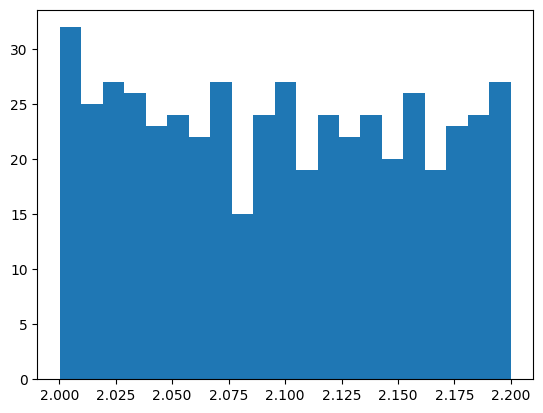

In [8]:
plt.hist(galaxy_params['lf'], bins=21)

In [9]:
from bpd.draw import draw_exponential_galsim


# now get corresponding target images
draw_params = {**galaxy_params}
draw_params["f"] = 10 ** draw_params.pop("lf")
draw_params["hlr"] = 10 ** draw_params.pop("lhlr")
# get noiseless images 
_draw_galsim = partial(draw_exponential_galsim, slen=63)
noiseless = []

for ii in range(n_gals):
    _params = {k: v[ii] for k, v in draw_params.items()}
    noiseless.append(_draw_galsim(**_params))

In [10]:
from bpd.utils import get_snr
snrs = [] 
for ii in range(500):
    snrs.append(get_snr(noiseless[ii], background=background))


(array([25., 61., 70., 65., 56., 53., 60., 45., 44., 21.]),
 array([6.59578133, 6.91471958, 7.23365831, 7.55259657, 7.8715353 ,
        8.19047356, 8.50941181, 8.82835007, 9.14728928, 9.46622753,
        9.78516579]),
 <BarContainer object of 10 artists>)

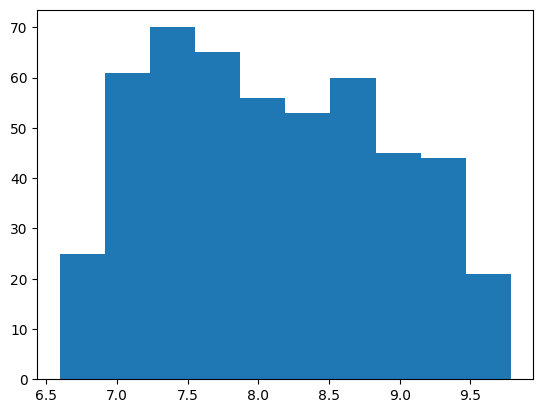

In [11]:
plt.hist(snrs)

In [12]:
# get target iamges
# now get corresponding target images
draw_params = {**galaxy_params}
draw_params["f"] = 10 ** draw_params.pop("lf")
draw_params["hlr"] = 10 ** draw_params.pop("lhlr")
target_images = get_target_images(
    nkey, draw_params, background=background, slen=slen, draw_type="exponential"
)
assert target_images.shape == (n_gals, slen, slen)

In [13]:
# try fitting a single galaxy below SNR < 10

# setup target density
draw_fnc = partial(draw_exponential, slen=slen, fft_size=fft_size)
_logprior = partial(
    interim_gprops_logprior, sigma_e=sigma_e_int, free_flux_hlr=True, free_dxdy=True
)
_loglikelihood = partial(
    gaussian_image_loglikelihood,
    draw_fnc=draw_fnc,
    background=background,
    free_flux_hlr=True,
    free_dxdy=True,
)

In [14]:
# interim samples are on 'sheared ellipticity'
true_params = vmap(get_true_params_from_galaxy_params)(galaxy_params)
true_params["dx"] = jnp.zeros_like(true_params["x"])
true_params["dy"] = jnp.zeros_like(true_params["y"])
fixed_params = {"x": true_params.pop("x"), "y": true_params.pop("y")}

In [15]:
def logtarget_images(
    params,
    data: Array,
    *,
    fixed_params,
    logprior_fnc,
    loglikelihood_fnc,
):
    return logprior_fnc(params) + loglikelihood_fnc(params, data, fixed_params)

In [16]:
# declare logtarget 
_logtarget = partial(
    logtarget_images,
    logprior_fnc=_logprior,
    loglikelihood_fnc=_loglikelihood,
)

In [17]:
# pipeline very simple test
def pipe(rng_key, target_image, init_positions,fixed_params, *, logtarget):
    _logtarget = partial(logtarget, fixed_params=fixed_params)
    return run_inference_nuts(
        rng_key, 
        data=target_image, 
        init_positions=init_positions, 
        logtarget=_logtarget, 
        is_mass_matrix_diagonal=True,
        n_samples=400,
        n_warmup_steps=500,
        max_num_doublings=5,
        initial_step_size=0.01,)

In [18]:
_pipe = jit(partial(pipe, logtarget=_logtarget))

# 1 galaxy and 1 chain

In [31]:
idx = 1

In [32]:
# test on one image

_init_position = {k:v[idx] for k,v in true_params.items()}
_fixed_position = {k:v[idx] for k,v in fixed_params.items()}
_init_position

{'e1': Array(0.07123611, dtype=float64),
 'e2': Array(-0.3017523, dtype=float64),
 'lf': Array(2.11417483, dtype=float64),
 'lhlr': Array(-0.37811446, dtype=float64),
 'dx': Array(0., dtype=float64),
 'dy': Array(0., dtype=float64)}

In [33]:
snrs[idx]

Array(8.191593, dtype=float32)

In [34]:
jnp.log10(target_images[idx].sum())

Array(2.20525114, dtype=float64)

In [35]:
# try deviation from truth
_init_position['lf']= 2.2
_init_position['e1'] = 0.12
_init_position['e2'] = -0.25

In [36]:
samples = _pipe(random.key(40), target_images[idx], _init_position, _fixed_position)

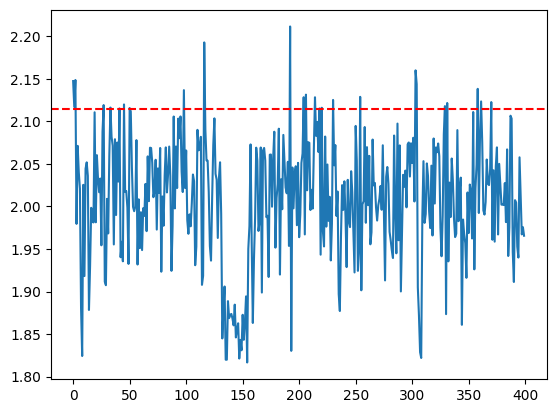

In [37]:
plt.plot(samples['lf'])
plt.axhline(true_params['lf'][idx], ls='--', c='r')

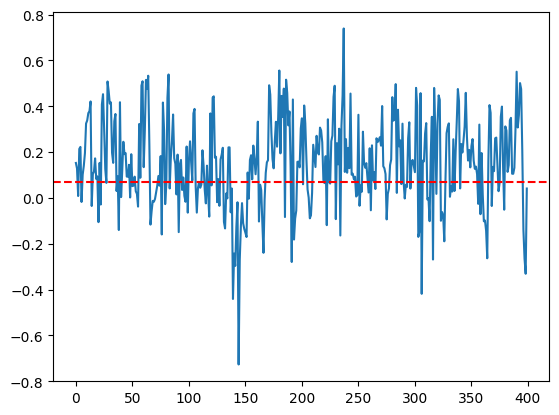

In [38]:
plt.plot(samples['e1'])
plt.axhline(true_params['e1'][idx], ls='--', c='r')

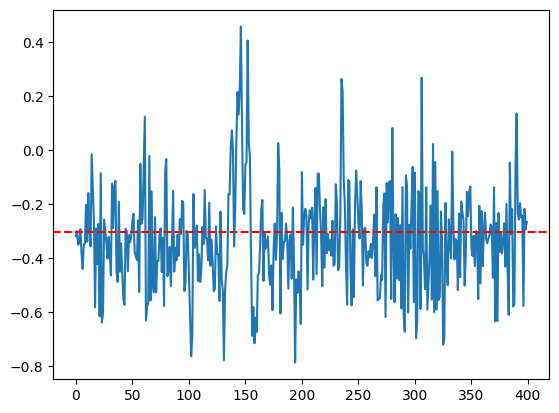

In [39]:
plt.plot(samples['e2'])
plt.axhline(true_params['e2'][idx], ls='--', c='r')

In [27]:
# notes: seems to work with mnd = 7, with mnd=5 sometimes seems like there are slight convernge issues

## Convergence

In [40]:
gkeys, ikeys = random.split(gkey, (2, 4))
gkeys.shape

(4,)

In [41]:
# test on one image
idx = 19
_fixed_position = {k:v[idx] for k,v in fixed_params.items()}
snrs[idx]

Array(6.803449, dtype=float32)

In [42]:
_true_params = {
    k:v[idx] for k,v in true_params.items()
}
_true_params

{'e1': Array(0.1858426, dtype=float64),
 'e2': Array(-0.46560966, dtype=float64),
 'lf': Array(2.0236198, dtype=float64),
 'lhlr': Array(-0.34846269, dtype=float64),
 'dx': Array(0., dtype=float64),
 'dy': Array(0., dtype=float64)}

In [43]:
init_positions = vmap(_init_fnc, in_axes=(0, None, None))(ikeys, target_images[idx], _true_params)

init_positions

{'dx': Array([0., 0., 0., 0.], dtype=float64, weak_type=True),
 'dy': Array([0., 0., 0., 0.], dtype=float64, weak_type=True),
 'e1': Array([0.2771039 , 0.23582594, 0.09680554, 0.22015415], dtype=float64),
 'e2': Array([-0.48804278, -0.38743826, -0.55021055, -0.37850426], dtype=float64),
 'lf': Array([1.70181166, 1.70181166, 1.70181166, 1.70181166], dtype=float64),
 'lhlr': Array([-0.35448995, -0.36103077, -0.33376381, -0.34320495], dtype=float64)}

In [44]:
vpipe = vmap(_pipe, in_axes=(0, None, 0 , None))
samples = vpipe(gkeys, target_images[idx], init_positions, _fixed_position)

In [45]:
samples['lf'].shape

(4, 400)

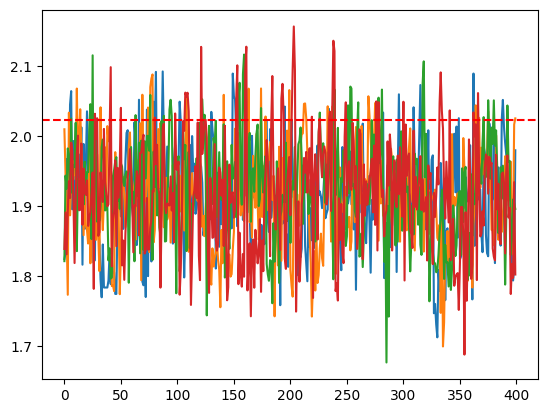

In [46]:
for ii in range(4):
    plt.plot(samples['lf'][ii])
plt.axhline(true_params['lf'][idx], ls='--', c='r')

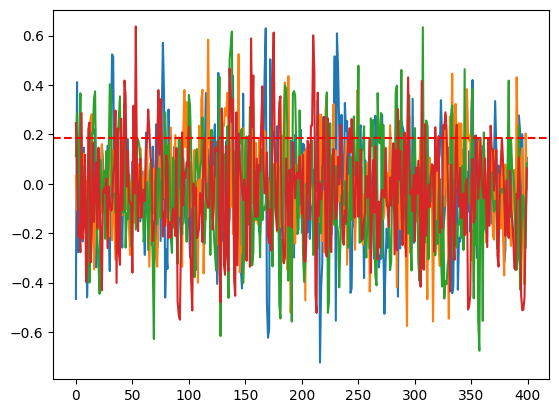

In [47]:
for ii in range(4):
    plt.plot(samples['e1'][ii])
plt.axhline(true_params['e1'][idx], ls='--', c='r')

In [48]:
get_rhat_all({k:v.reshape(1, 4, 400) for k,v in samples.items()})

INFO: Computing R-hats...


100%|██████████| 1/1 [00:00<00:00, 879.31it/s]


{'dx': array([0.99960374]),
 'dy': array([1.00231903]),
 'e1': array([0.99968217]),
 'e2': array([0.99884193]),
 'lf': array([1.0008833]),
 'lhlr': array([1.00074582])}

# Rhat for all galaxies

In [52]:
_keys = random.split(gkey, (n_gals, 4, 2))
gkeys = _keys[...,0]
ikeys = _keys[...,1]

In [53]:
vpipe = vmap(vmap(_pipe, in_axes=(0, None, 0 , None)))

In [57]:
init_positions = vmap(vmap(_init_fnc, in_axes=(0, None, None)))(ikeys, target_images, true_params)
init_positions['lf'][2]

Array([2.01260684, 2.01260684, 2.01260684, 2.01260684], dtype=float64)

In [58]:
samples = vpipe(gkeys, target_images, init_positions, fixed_params)

In [59]:
rhats = get_rhat_all(samples)

INFO: Computing R-hats...


100%|██████████| 500/500 [00:00<00:00, 1036.99it/s]


In [63]:
rhats['e1'].shape

(500,)

In [70]:
for k in rhats:
    mask = (np.abs(rhats[k]) > 1.05) | (np.abs(rhats[k]) <0.99)
    print(k, sum(mask))
    print(np.where(mask))

dx 0
(array([], dtype=int64),)
dy 0
(array([], dtype=int64),)
e1 10
(array([ 18,  48,  57, 122, 156, 269, 323, 456, 460, 473]),)
e2 10
(array([ 18,  48,  57, 122, 156, 269, 323, 456, 460, 473]),)
lf 0
(array([], dtype=int64),)
lhlr 10
(array([ 18,  48,  57, 122, 156, 269, 323, 456, 460, 473]),)


In [113]:
## examaine some
idx = 460

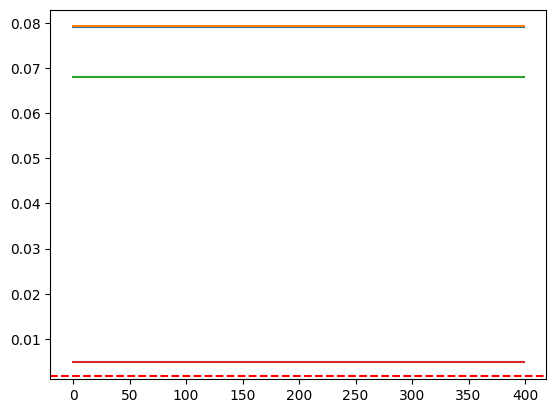

In [114]:
for ii in range(4):
    plt.plot(samples['e1'][idx][ii])
plt.axhline(true_params['e1'][idx], ls='--', c='r')

In [115]:
{k:v[idx] for k,v in init_positions.items()}

{'dx': Array([0., 0., 0., 0.], dtype=float64, weak_type=True),
 'dy': Array([0., 0., 0., 0.], dtype=float64, weak_type=True),
 'e1': Array([0.07912041, 0.0791633 , 0.06797017, 0.00477799], dtype=float64),
 'e2': Array([0.0644599 , 0.18997068, 0.16223528, 0.21062428], dtype=float64),
 'lf': Array([nan, nan, nan, nan], dtype=float64),
 'lhlr': Array([-0.31465755, -0.33543257, -0.31713277, -0.31626475], dtype=float64)}

In [116]:
{k:v[idx] for k,v in true_params.items()}

{'e1': Array(0.0018288, dtype=float64),
 'e2': Array(0.12055929, dtype=float64),
 'lf': Array(2.00643786, dtype=float64),
 'lhlr': Array(-0.3234413, dtype=float64),
 'dx': Array(0., dtype=float64),
 'dy': Array(0., dtype=float64)}

In [117]:
np.sum(target_images[idx])

Array(-2.90060523, dtype=float64)

Array(6.698346, dtype=float32)

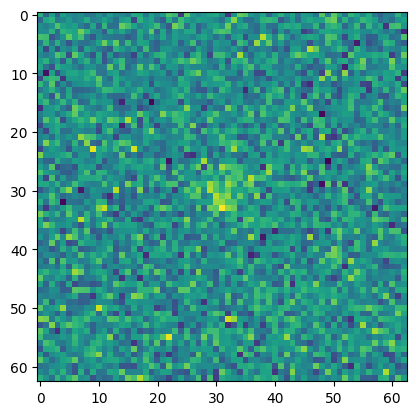

In [118]:
plt.imshow(target_images[idx])
snrs[idx]